
# Regression

In this task you will be training a regression model on the flight dataset. This dataset contains all flight information including delays by airline. You have to predict the delay in arrival time given by 'ArrDelayMinutes' column.

### Column Description:

1. FlightDate:	Flight Date (yyyymmdd)

2. Origin:	Origin Airport

3. Dest: Destination Airport

4. CRSDepTime:	CRS(Scheduled) Departure Time (local time: hhmm)

5. CRSArrTime: CRS(Scheduled) Arrival Time (local time: hhmm)

6. DepTime: Actual Departure Time (local time: hhmm)

7. DepDelayMinutes:	Difference in minutes between scheduled and actual departure time. Early departures set to 0.

8. DepDel15:	Departure Delay Indicator, 15 Minutes or More (1=Yes)

9. DepartureDelayGroups:	Departure Delay intervals.

10. TaxiOut:	Taxi Out Time, in Minutes

11. ArrDelayMinutes:	Difference in minutes between scheduled and actual arrival time.

12. AirTime:	Flight Time, in Minutes






In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**: Load the provided CSV file into a pandas DataFrame. Display the first few rows to understand the structure of the dataset.

**Dataset Overview**: Display the shape of the dataset and list all the column names. Identify the types of data (numerical, categorical, datetime) present in the dataset.

In [16]:
# code
flight_df_uncleaned = pd.read_csv("data/regression_unclean.csv")
print("First 5 rows of df_flight:")
print(flight_df_uncleaned.head())
print(50 * "-")
print(f"Shape of df_flight: {flight_df_uncleaned.shape}")
print(50 * "-")
print(f"Columns of df_flight: {flight_df_uncleaned.columns.tolist()}")
print(50 * "-")
print(f"Data types of df_flight:\n{flight_df_uncleaned.dtypes}")

First 5 rows of df_flight:
   FlightDate                 Airline Origin Dest  CRSDepTime  CRSArrTime  \
0  2022-02-23   United Air Lines Inc.    EWR  SEA         705        1014   
1  2022-07-13   SkyWest Airlines Inc.    IDA  DFW        1345        1738   
2  2022-04-19    Delta Air Lines Inc.    SEA  SAN        1925        2209   
3  2022-05-05  American Airlines Inc.    CLT  BDL        1102        1258   
4  2022-02-16    Alaska Airlines Inc.    SEA  TPA         755        1610   

  Distance DepDelayMinutes  DepDel15  DepartureDelayGroups TaxiOut  AirTime  \
0   2402.0             0.0       0.0                  -1.0    22.0    333.0   
1   1095.0             7.0       0.0                   0.0   38.|0    132.0   
2   1050.0             2.0       0.0                   0.0  9999.0    134.0   
3    644.0             9.0       0.0                   0.0    18.0     86.0   
4   2520.0             0.0       0.0                  -1.0    18.0    281.0   

   ArrDelayMinutes  
0             

## Q1:(10 pts) Train Linear Regression on Uncleaned Data


### 1.1 Data Preparation:

a. From the dataset, exclude the FlightDate column.

b. Review the df_uncleaned DataFrame to identify columns that should be numeric but are stored as strings. Convert these columns to numeric types, ignoring any non-convertible values

c. You should   and prepare the feature set (X) and the target variable (y) for predicting ArrDelayMinutes. Convert categorical variables into dummy variables. For numerical columns, fill null values with 0.

### 1.2 Model Training and Evaluation:

Train a Linear Regression model using the prepared dataset. Evaluate the model by calculating the Root Mean Squared Error (RMSE) on the test set.

### 1.3 Cross-Validation:

Implement 5-fold cross-validation on the uncleaned dataset using the Linear Regression model. Calculate and report the RMSE for each fold as well as the mean and standard deviation of these RMSE values.


In [17]:
# Q1.1.a - exclude the FlightDate column
df_uncleaned = flight_df_uncleaned.copy()
df_uncleaned.drop(columns= ['FlightDate'], inplace=True)

# Q1.1.b - review the data types of the columns and convert them strings to numeric values
print("Data types of df_uncleaned before conversion:\n", df_uncleaned.dtypes)
print(50 * "-")
print(df_uncleaned.head())
print(50 * "-")

# Just to check the unique values in the object columns before conversion   
#for col in df_uncleaned.columns:
#    if df_uncleaned[col].dtype == 'object':
#        print(f"Unique types in {col}: {df_uncleaned[col].unique()}")

print(
f"""---------------------------------------------------------------------------
From the unique values, we can see that 'Distance','DepDelayMinutes', 
and 'TaxiOut' columns are numeric but stored as strings. We will convert 
them to numeric values, coercing errors to NaN.
---------------------------------------------------------------------------""")

# Convert object columns to numeric, coercing errors to NaN
false_columns = ['Distance', 'DepDelayMinutes', 'TaxiOut']

for col in df_uncleaned.columns:
    if col in false_columns:
        df_uncleaned[col] = pd.to_numeric(df_uncleaned[col], errors='coerce')

print("Data types of df_uncleaned after conversion false object to numeric:\n", df_uncleaned.dtypes)
print(50 * "-")

# Q1.1.c - fill nan values with 0. Convert categorical variables to dummy variables. 
# Split the data into features and target variable( y = "ArrDelayMinutes")

X = df_uncleaned.drop(columns=['ArrDelayMinutes'])
y = df_uncleaned['ArrDelayMinutes']

X = X.fillna(0) # Fill NaN values with 0 for features

# Convert categorical variables to dummy variables
X = pd.get_dummies(X)



Data types of df_uncleaned before conversion:
 Airline                  object
Origin                   object
Dest                     object
CRSDepTime                int64
CRSArrTime                int64
Distance                 object
DepDelayMinutes          object
DepDel15                float64
DepartureDelayGroups    float64
TaxiOut                  object
AirTime                 float64
ArrDelayMinutes         float64
dtype: object
--------------------------------------------------
                  Airline Origin Dest  CRSDepTime  CRSArrTime Distance  \
0   United Air Lines Inc.    EWR  SEA         705        1014   2402.0   
1   SkyWest Airlines Inc.    IDA  DFW        1345        1738   1095.0   
2    Delta Air Lines Inc.    SEA  SAN        1925        2209   1050.0   
3  American Airlines Inc.    CLT  BDL        1102        1258    644.0   
4    Alaska Airlines Inc.    SEA  TPA         755        1610   2520.0   

  DepDelayMinutes  DepDel15  DepartureDelayGroups TaxiOut  

In [18]:
# Q1.2 - Train a Linear Regression model using the prepared dataset. 
# Evaluate the model by calculating the Root Mean Squared Error (RMSE) on the test set.

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Linear Regression model and evaluate it using RMSE
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
initial_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Initial RMSE: {initial_rmse}")

Initial RMSE: 17.56078747789211


In [19]:
# Q1.3 - Cross-Validation
# Implement 5-fold cross-validation on the uncleaned dataset using the Linear Regression model. 
# Calculate and report the RMSE for each fold as well as the mean and standard deviation of these RMSE values.

scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-scores)

print("RMSE for each fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

RMSE for each fold: [39.7089456  16.75317242 17.59324359 18.45653787 16.3743119 ]
Mean RMSE: 21.77724227353312
Std RMSE: 8.994574380440916


## Q2:(20 pts) Data Cleaning and Preprocessing

Read CSV into a new variable

In [20]:
# Q2 - Read the uncleaned dataset again.
flight_df_cleaning = pd.read_csv("data/regression_unclean.csv")

### 2.1(4 pts)  Clean Data

a. Identify columns that should be numeric but are stored as strings. Write code to convert these columns to numeric types, but this time you won't be ignoring any non-convertible values. Identify why these values are non-convertible.(Hint: Use errors='raise' in your conversion process and identify problematic entries.)

b. Develop a function to correct the identified problematic entries, enabling successful conversion of the affected columns to numeric types.



In [21]:
# Q2.1.a - Identify and handle outliers in the dataset.

print(f"Data types:\n{flight_df_cleaning.dtypes}")
print(50 * "-")
print(flight_df_cleaning.head())
print(50 * "-")

# Convert object columns to numeric, erroring out if conversion fails to identify any non-numeric values
false_columns = ['Distance', 'DepDelayMinutes', 'TaxiOut']

for col in false_columns:
    problematic_values = []
    for value in flight_df_cleaning[col]:
        try:
            pd.to_numeric(value, errors='raise')
        except (ValueError, TypeError):
            problematic_values.append(value)
    print(f"Problematic values in {col}: {set(problematic_values)}")

Data types:
FlightDate               object
Airline                  object
Origin                   object
Dest                     object
CRSDepTime                int64
CRSArrTime                int64
Distance                 object
DepDelayMinutes          object
DepDel15                float64
DepartureDelayGroups    float64
TaxiOut                  object
AirTime                 float64
ArrDelayMinutes         float64
dtype: object
--------------------------------------------------
   FlightDate                 Airline Origin Dest  CRSDepTime  CRSArrTime  \
0  2022-02-23   United Air Lines Inc.    EWR  SEA         705        1014   
1  2022-07-13   SkyWest Airlines Inc.    IDA  DFW        1345        1738   
2  2022-04-19    Delta Air Lines Inc.    SEA  SAN        1925        2209   
3  2022-05-05  American Airlines Inc.    CLT  BDL        1102        1258   
4  2022-02-16    Alaska Airlines Inc.    SEA  TPA         755        1610   

  Distance DepDelayMinutes  DepDel15  Depart

In [22]:
# import regex library
import re

def fix_numeric_string(value):
    if isinstance(value, str):
        # Remove any non-numeric characters (except for the decimal point)
        # Assume that corrupted values like '4,,4.0','1||5.0', '9.,#0' should be cleaned to '44.0', '15.0', '9.0'.
        return re.sub(r'[^\d.]', '', value) # r[^\d.] matches any character that is not a digit or a decimal point and replaces it with an empty string
    return value # if it is a numeric or nan value, return the value as is

# Apply the function to the corrupted columns
for col in false_columns:
    flight_df_cleaning[col] = flight_df_cleaning[col].apply(fix_numeric_string)
    flight_df_cleaning[col] = pd.to_numeric(flight_df_cleaning[col], errors='coerce')

print(f"Data types after fixing numeric strings:\n{flight_df_cleaning.dtypes}")
print(50 * "-")
print("NaN counts after fixing:")
print(flight_df_cleaning[false_columns].isna().sum())
print(flight_df_cleaning.head())

Data types after fixing numeric strings:
FlightDate               object
Airline                  object
Origin                   object
Dest                     object
CRSDepTime                int64
CRSArrTime                int64
Distance                float64
DepDelayMinutes         float64
DepDel15                float64
DepartureDelayGroups    float64
TaxiOut                 float64
AirTime                 float64
ArrDelayMinutes         float64
dtype: object
--------------------------------------------------
NaN counts after fixing:
Distance           0
DepDelayMinutes    0
TaxiOut            0
dtype: int64
   FlightDate                 Airline Origin Dest  CRSDepTime  CRSArrTime  \
0  2022-02-23   United Air Lines Inc.    EWR  SEA         705        1014   
1  2022-07-13   SkyWest Airlines Inc.    IDA  DFW        1345        1738   
2  2022-04-19    Delta Air Lines Inc.    SEA  SAN        1925        2209   
3  2022-05-05  American Airlines Inc.    CLT  BDL        1102        

### 2.2(3 pts) Feature Engineering:

Write a function for feature engineering that includes:

1. Extracting Year, Month, Day, and Weekday from FlightDate. You should create new columns each for Year, Month, Day, and Weekday.

2. Create a new categorical column 'DepTimePeriod' by converting 'CRSDepTime' into categorical time periods (Night, Morning, Afternoon, Evening).

    - [6:00 AM - 12:00 PM): Morning
    - [12:00 PM - 6:00 PM): Afternoon
    - [6:00 PM - 12:00 AM): Evening
    - [12:00 AM - 6:00 AM): Night


4. Create a new categorical column 'Season' by categorizing 'Month' into seasons (Winter, Spring, Summer, Fall).

   - December, January, February: Winter
   - March, April, May: Spring
   - June, July, August: Summer
   - September, October, November: Fall   

Apply this function to the dataset and display the first few rows of the transformed dataset.


In [23]:
def feature_engineering(flight_df_cleaning):
    flight_df_cleaning = flight_df_cleaning.copy()

    # 1. Extracting Year, Month, Day, and Weekday from FlightDate.
    flight_df_cleaning['FlightDate'] = pd.to_datetime(flight_df_cleaning['FlightDate'])
    flight_df_cleaning['Year'] = flight_df_cleaning['FlightDate'].dt.year
    flight_df_cleaning['Month'] = flight_df_cleaning['FlightDate'].dt.month
    flight_df_cleaning['Day'] = flight_df_cleaning['FlightDate'].dt.day
    flight_df_cleaning['Weekday'] = flight_df_cleaning['FlightDate'].dt.weekday # Monday=0, Sunday=6

    # Drop the original FlightDate column after extracting features
    flight_df_cleaning = flight_df_cleaning.drop(columns=['FlightDate'])
    
    # 2. Create a new feature 'DepTimePeriod' based on the 'CRSDepTime' column to categorize departure times into periods of the day (e.g., Morning, Afternoon, Evening, Night).
    def get_dep_time_period(time):
        hour = time // 100
        if 6 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 18:
            return 'Afternoon'
        elif 18 <= hour < 24:
            return 'Evening'
        else:
            return 'Night' # 0-6
        
    flight_df_cleaning['DepTimePeriod'] = flight_df_cleaning['CRSDepTime'].apply(get_dep_time_period)

    # 3. Create a new feature 'Season' based on the 'Month' column to categorize months into seasons (e.g., Winter, Spring, Summer, Fall).
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'

    flight_df_cleaning['Season'] = flight_df_cleaning['Month'].apply(get_season)

    return flight_df_cleaning


flight_df_cleaning = feature_engineering(flight_df_cleaning)


print(flight_df_cleaning.head())


                  Airline Origin Dest  CRSDepTime  CRSArrTime  Distance  \
0   United Air Lines Inc.    EWR  SEA         705        1014    2402.0   
1   SkyWest Airlines Inc.    IDA  DFW        1345        1738    1095.0   
2    Delta Air Lines Inc.    SEA  SAN        1925        2209    1050.0   
3  American Airlines Inc.    CLT  BDL        1102        1258     644.0   
4    Alaska Airlines Inc.    SEA  TPA         755        1610    2520.0   

   DepDelayMinutes  DepDel15  DepartureDelayGroups  TaxiOut  AirTime  \
0              0.0       0.0                  -1.0     22.0    333.0   
1              7.0       0.0                   0.0     38.0    132.0   
2              2.0       0.0                   0.0   9999.0    134.0   
3              9.0       0.0                   0.0     18.0     86.0   
4              0.0       0.0                  -1.0     18.0    281.0   

   ArrDelayMinutes  Year  Month  Day  Weekday DepTimePeriod  Season  
0              0.0  2022      2   23        2 

### 2.3(3 pts) Remove outliers from numerical columns.

a. Create boxplot for each numerical column. Identify which columns have extreme outliers.

b. Remove outliers using Interquartile Range.

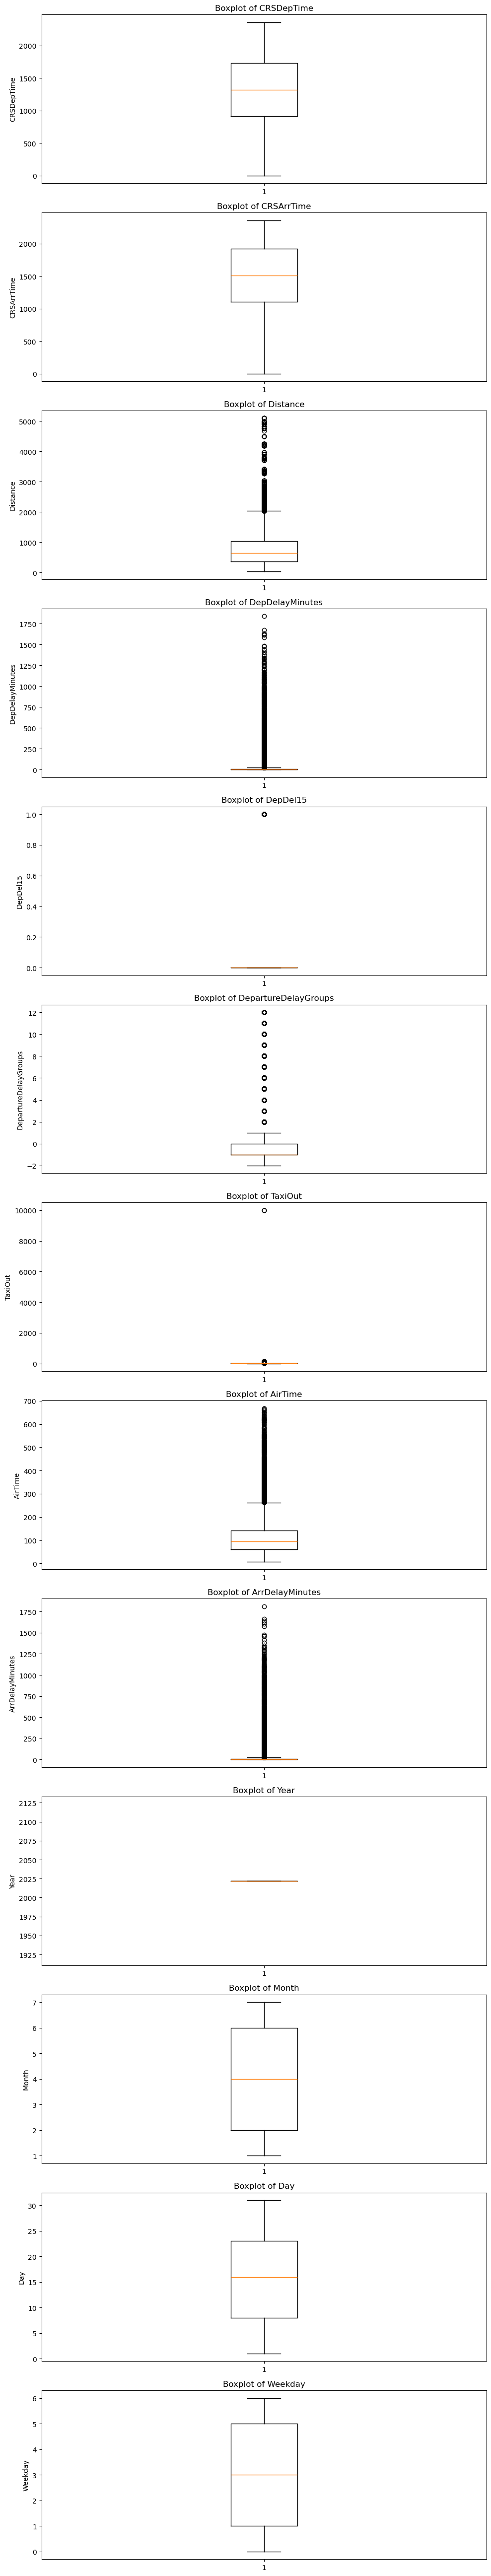

          CRSDepTime     CRSArrTime      Distance  DepDelayMinutes  \
count  200000.000000  200000.000000  200000.00000    200000.000000   
mean     1327.966765    1483.845275     799.28085        16.039455   
std       490.447245     518.475454     594.82744        52.306581   
min         1.000000       1.000000      31.00000         0.000000   
25%       911.000000    1101.000000     368.00000         0.000000   
50%      1320.000000    1510.000000     643.00000         0.000000   
75%      1732.000000    1919.000000    1035.00000        10.000000   
max      2359.000000    2359.000000    5095.00000      1839.000000   

            DepDel15  DepartureDelayGroups        TaxiOut        AirTime  \
count  200000.000000         200000.000000  200000.000000  200000.000000   
mean        0.217265              0.212050      17.140505     111.050125   
std         0.412385              2.344901      45.643859      70.145757   
min         0.000000             -2.000000       1.000000       8

In [24]:
# Q2.3.a - Create boxplot for each numerical column. Identify which columns have extreme outliers.

# Get numerical columns only
numerical_cols = flight_df_cleaning.select_dtypes(include='number').columns.tolist()

# Create boxplot for each numerical column
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(flight_df_cleaning[col].dropna())
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


print(flight_df_cleaning[numerical_cols].describe())
print(f"""---------------------------------------------------------------------------
From the boxplots, columns with extreme outliers are Distance, DepDelayMinutes, DepartureDelayGroups, TaxiOut, AirTime, and ArrDelayMinutes.
These columns have some extremely high values compared to the rest of the data.
CRSDeptime and CRSArrTime have normal distributions without extreme outliers.
DepDel15 is a binary variable and does not have extreme outliers.
Month and Day have normal distributions without extreme outliers.
Year has constant value which is 2022.
Weekday has normal distribution without extreme outliers.
---------------------------------------------------------------------------""")


In [25]:
# Q2.3.b - Remove outliers using IQR

exclude_cols = ['CRSDepTime', 'CRSArrTime', 'DepDel15','Year', 'Month', 'Day', 'Weekday']

X_numeric = flight_df_cleaning.select_dtypes(include='number').drop(columns=exclude_cols)

Q1 = X_numeric.quantile(0.25)
Q3 = X_numeric.quantile(0.75)
IQR = Q3 - Q1

mask = ~((X_numeric < (Q1 - 1.5 * IQR)) | (X_numeric > (Q3 + 1.5 * IQR))).any(axis=1)

print(f"Shape before cleaning: {flight_df_cleaning.shape}")
flight_df_cleaning = flight_df_cleaning[mask]
print(f"Shape after cleaning: {flight_df_cleaning.shape}")
print(f"Rows removed: {(~mask).sum()}")

Shape before cleaning: (200000, 18)
Shape after cleaning: (147299, 18)
Rows removed: 52701


### 2.4(10 pts) Preprocessing and Transformation Pipeline

**Pipeline Creation**: Create a preprocessing pipeline that includes:

1. Filling missing values(SimpleImputer, startegy = 'mean') and applying standard scaling(StandardScalar) for numerical features.

2. For each categorical column, calculate and print the total number of unique categories. Identify categorical columns with low and high cardinality based on the calculated number of unique categories. Column with >50 categories should be considered as high cardinality column

    a. Filling missing values(SimpleImputer, startegy = 'most_frequent') and applying one-hot encoding(OneHotEncoder) for categorical features with low cardinality.

    b. Filling missing values(SimpleImputer, startegy = 'most_frequent') and applying ordinal encoding(Ordinal Encoder) for categorical features with high cardinality.

Use the pipeline to transform the dataset.

In [26]:
# 2.4 - Preprocessing and Transformation Pipeline
X = flight_df_cleaning.drop(columns=['ArrDelayMinutes'])
y = flight_df_cleaning['ArrDelayMinutes']

# Numeric columns
numerical_cols = X.select_dtypes(include='number').columns.tolist()

# Categorical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

# Split categorical columns into low and high cardinality
low_cardinality_cols = []
high_cardinality_cols = []

for col in categorical_cols:
    n_unique = X[col].nunique()
    print(f"Column '{col}' has {n_unique} unique values.")
    if n_unique > 50:
        high_cardinality_cols.append(col)
    else:
        low_cardinality_cols.append(col)

print("\nLow cardinality categorical columns:", low_cardinality_cols)
print("High cardinality categorical columns:", high_cardinality_cols)


Numerical columns: ['CRSDepTime', 'CRSArrTime', 'Distance', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'TaxiOut', 'AirTime', 'Year', 'Month', 'Day', 'Weekday']

Categorical columns: ['Airline', 'Origin', 'Dest', 'DepTimePeriod', 'Season']
Column 'Airline' has 21 unique values.
Column 'Origin' has 369 unique values.
Column 'Dest' has 372 unique values.
Column 'DepTimePeriod' has 4 unique values.
Column 'Season' has 3 unique values.

Low cardinality categorical columns: ['Airline', 'DepTimePeriod', 'Season']
High cardinality categorical columns: ['Origin', 'Dest']


In [27]:
# Numeric attributes pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', StandardScaler()),
])

# Low cardinality attributes pipeline
low_cardinality_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# High cardinality attributes pipeline
high_cardinality_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

# Combine numerical and categorical pipelines
preprocessor = ColumnTransformer([
    ('num',       num_pipeline, numerical_cols),
    ('low_card',  low_cardinality_pipeline,  low_cardinality_cols),
    ('high_card', high_cardinality_pipeline, high_cardinality_cols)
])

X_clean = preprocessor.fit_transform(X)

print(f"Shape before pipeline: {X.shape}")
print(f"Shape after pipeline:  {X_clean.shape}")

Shape before pipeline: (147299, 17)
Shape after pipeline:  (147299, 42)


## Q3:(6 pts) Train Linear Regression Model on Cleaned Data

### 3.1 Model Training:

Train a new Linear Regression model using the preprocessed (cleaned and transformed) dataset.

### 3.2 Model Evaluation:

Evaluate the new model by calculating RMSE on the test set. Compare these metrics with those obtained from the model trained on uncleaned data.

### 3.3 Cross-Validation:

Perform 5-fold cross-validation on the cleaned dataset using the new Linear Regression model. Calculate and report the RMSE for each fold as well as the mean and standard deviation of these RMSE values.

In [28]:
# 3.1 - Train a new Linear Regression model using the preprocessed (cleaned and transformed) dataset.

X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

model_clean = LinearRegression()
model_clean.fit(X_train, y_train)
y_pred_clean = model_clean.predict(X_test)

# 3.2 - Calculate RMSE for the cleaned model
clean_rmse = np.sqrt(mean_squared_error(y_test, y_pred_clean))
print(f"Uncleaned RMSE: {initial_rmse}")
print(f"\nRMSE after cleaning and preprocessing: {clean_rmse}")
print(f"RMSE improvement: {initial_rmse - clean_rmse}")

# 3.3 - Cross-Validation on the cleaned dataset
clean_cv_scores = cross_val_score(model_clean, X_clean, y, scoring='neg_mean_squared_error', cv=5)
clean_cv_rmse_scores = np.sqrt(-clean_cv_scores)
print("\nCleaned RMSE for each fold:", clean_cv_rmse_scores)
print("Mean RMSE after cleaning:", clean_cv_rmse_scores.mean())
print("Std RMSE after cleaning:", clean_cv_rmse_scores.std())
print(f"The improvement in RMSE standard deviation: {rmse_scores.std() - clean_cv_rmse_scores.std()}")
print("""--------------------------------------------------------------------------
After cleaning, the RMSE has improved significantly,
indicating that the data cleaning and preprocessing steps have enhanced the model's performance and 
it has really low standard deviation across the folds, indicating consistent performance.
--------------------------------------------------------------------------""")

Uncleaned RMSE: 17.56078747789211

RMSE after cleaning and preprocessing: 3.524246341079322
RMSE improvement: 14.036541136812787

Cleaned RMSE for each fold: [3.53255836 3.5539751  3.57183234 3.55574536 3.48945122]
Mean RMSE after cleaning: 3.5407124751314383
Std RMSE after cleaning: 0.028511528144825667
The improvement in RMSE standard deviation: 8.96606285229609
--------------------------------------------------------------------------
After cleaning, the RMSE has improved significantly,
indicating that the data cleaning and preprocessing steps have enhanced the model's performance and 
it has really low standard deviation across the folds, indicating consistent performance.
--------------------------------------------------------------------------


## Q4:(4 pts) Report

a. Report the Root Mean Square Error (RMSE) values before and after performing data cleaning. Discuss the observed changes in RMSE values and provide insights into the effectiveness of data cleaning.

b. Explain the role of cross-validation in your analysis and interpret the significance of changes in standard deviation values pre and post-data cleaning. How does the standard deviation inform you about the model's performance consistency?

*a)* 

Uncleaned RMSE = 17.56078747789211
Cleaned RMSE = 3.524246341079322
RMSE improvement = 14.036541136812787

Before cleaning, corrupted values were coerced to NaN and filled with 0, which introduced noise into the model.

After cleaning, proper imputation, scaling, outlier removal, and feature engineering significantly reduced the error.

RMSE dropped from 17.56 to 3.52.

*b)*

Instead of testing the model once, which could be lucky or unlucky, CV splits the data into 5 folds and tests 5 times and giving us a more reliable estimate of model performance.

Uncleaned RMSE for each fold: [39.7089456  16.75317242 17.59324359 18.45653787 16.3743119 ]
Cleaned RMSE for each fold: [3.53255836 3.5539751  3.57183234 3.55574536 3.48945122]

Mean RMSE from Uncleaned CV = 21.77724227353312
Mean RMSE from Cleaned CV = 3.5407124751314383

This is exactly why CV is important because our single test in uncleaned model got lucky. RMSE was 17.56078747789211. The old model is actually worse.

But we have to see that in uncleaned model, std is 8.994574380440916 and in cleaned model, std is 0.028511528144825667. There is a huge differences and the std means how consistent our model is. Lower std means the model is consistent and higher std means the model is not consistent.

The improvement in RMSE std is 8.96606285229609. Our model is consistent after the cleaning and process step.
